In [ ]:
# Model names
models = ["YOLO", "RT-DETR"]

# Metrics
precision = [0.997, 0.996]
recall = [0.992, 0.997]
map50 = [0.995, 0.995]
map5095 = [0.924, 0.939]
speed = [4, 37]   # average ms/image

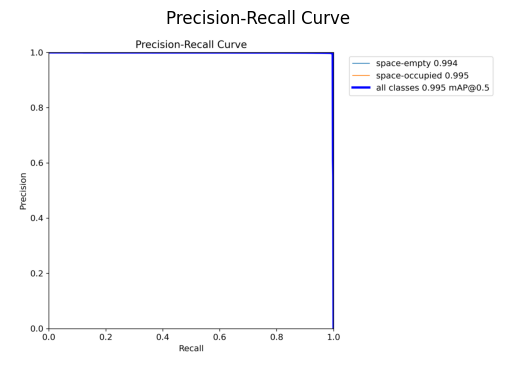

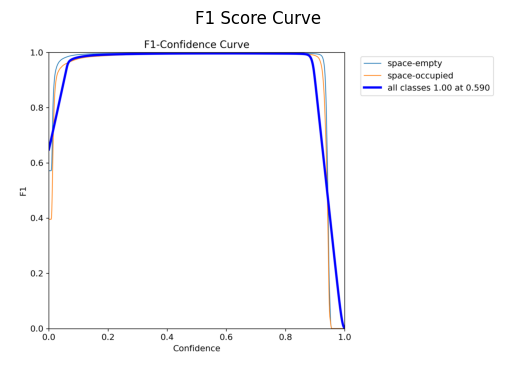

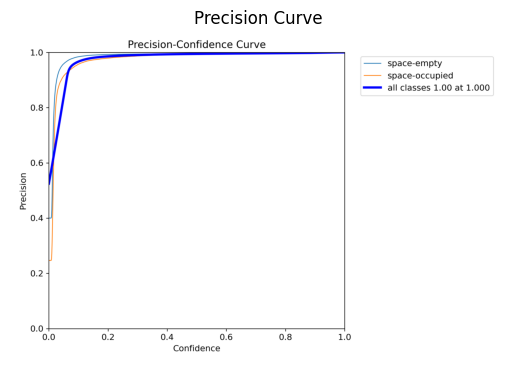

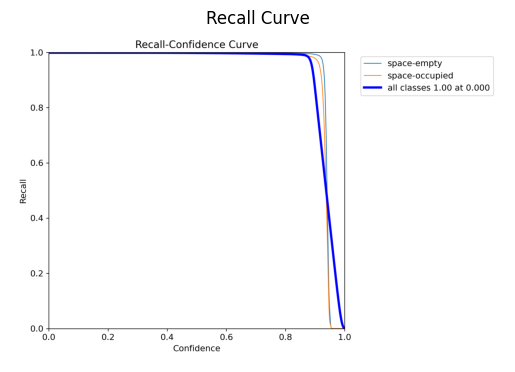

In [ ]:
import matplotlib.pyplot as plt
import cv2

paths = [
    "/content/runs/detect/val/BoxPR_curve.png",
    "/content/runs/detect/val/BoxF1_curve.png",
    "/content/runs/detect/val/BoxP_curve.png",
    "/content/runs/detect/val/BoxR_curve.png"
]

titles = [
    "Precision-Recall Curve",
    "F1 Score Curve",
    "Precision Curve",
    "Recall Curve"
]

for i in range(len(paths)):
    img = cv2.imread(paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure()
    plt.imshow(img)
    plt.title(titles[i])
    plt.axis("off")
    plt.show()

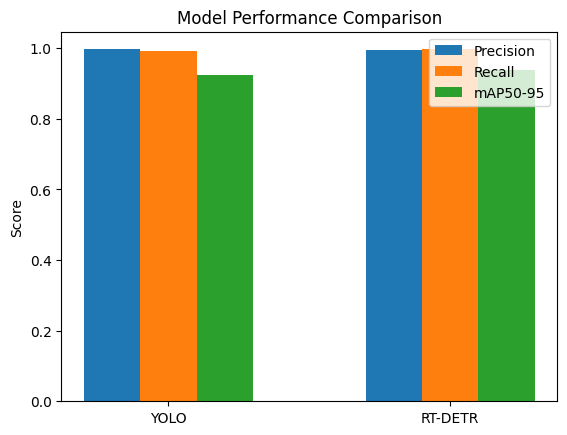

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(models))
width = 0.2

plt.figure()

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, map5095, width, label="mAP50-95")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

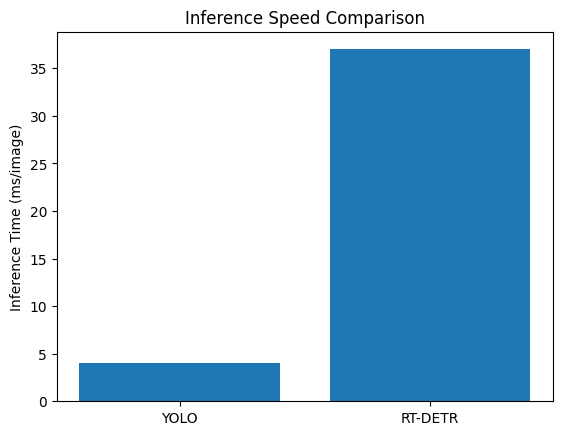

In [ ]:
plt.figure()

plt.bar(models, speed)

plt.ylabel("Inference Time (ms/image)")
plt.title("Inference Speed Comparison")

plt.show()

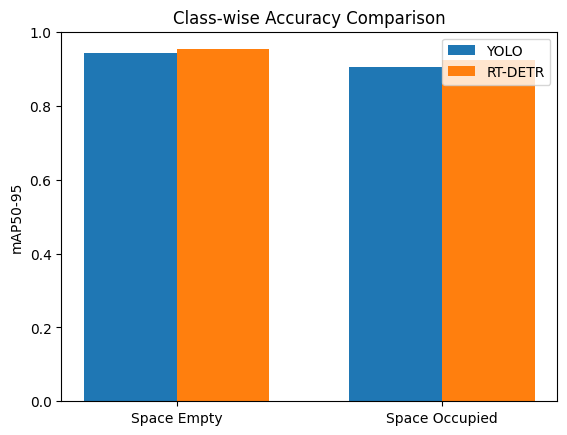

In [ ]:
classes = ["Space Empty", "Space Occupied"]

yolo_scores = [0.942, 0.906]
rtdetr_scores = [0.953, 0.925]

x = np.arange(len(classes))
width = 0.35

plt.figure()

plt.bar(x - width/2, yolo_scores, width, label="YOLO")
plt.bar(x + width/2, rtdetr_scores, width, label="RT-DETR")

plt.xticks(x, classes)
plt.ylabel("mAP50-95")
plt.title("Class-wise Accuracy Comparison")
plt.legend()

plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.0 ms, read: 0.4±0.1 MB/s, size: 316.6 KB)
val: Scanning /content/drive/MyDrive/pklot_yolo21/val/labels.cache... 670 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 670/670 108.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 42/42 1.1s/it 44.8s
                   all        670      63722      0.997      0.997      0.995      0.924
  

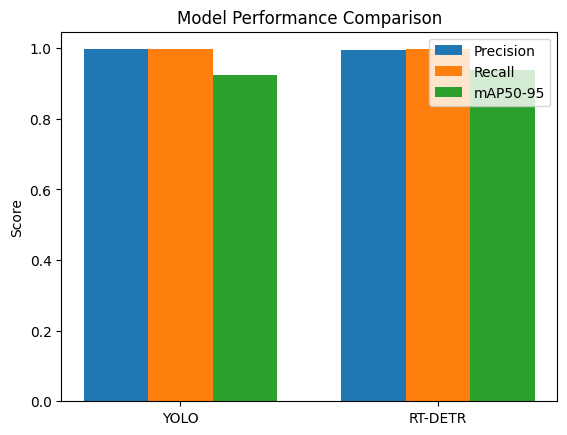

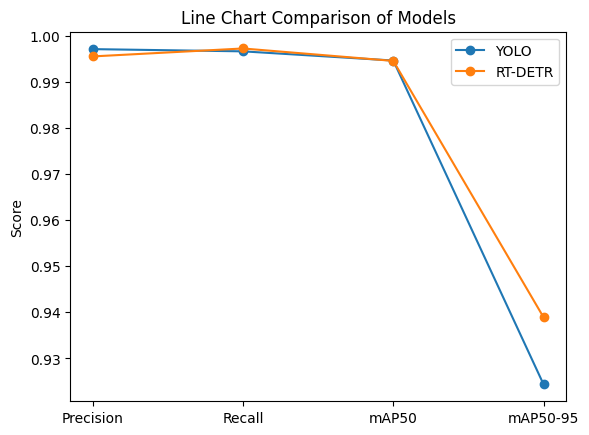

<Figure size 640x480 with 0 Axes>

In [ ]:
!pip install ultralytics
from ultralytics import YOLO, RTDETR

# Load trained models
model1 = YOLO("/content/drive/MyDrive/pklot_models/best.pt")
model2 = RTDETR("/content/drive/MyDrive/pklot_models/best1.pt")
# Run validation
yaml_path = "/content/drive/MyDrive/pklot_yolo21/data.yaml"
results_yolo = model1.val(data=yaml_path)
results_rtdetr = model2.val(data=yaml_path)
# YOLO metrics
yolo_precision = results_yolo.box.mp
yolo_recall = results_yolo.box.mr
yolo_map50 = results_yolo.box.map50
yolo_map5095 = results_yolo.box.map

# RT-DETR metrics
rtdetr_precision = results_rtdetr.box.mp
rtdetr_recall = results_rtdetr.box.mr
rtdetr_map50 = results_rtdetr.box.map50
rtdetr_map5095 = results_rtdetr.box.map
import matplotlib.pyplot as plt
import numpy as np

models = ["YOLO", "RT-DETR"]

precision = [yolo_precision, rtdetr_precision]
recall = [yolo_recall, rtdetr_recall]
map5095 = [yolo_map5095, rtdetr_map5095]

x = np.arange(len(models))
width = 0.25

plt.figure()

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, map5095, width, label="mAP50-95")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()
metrics_names = ["Precision", "Recall", "mAP50", "mAP50-95"]

yolo_values = [
    yolo_precision,
    yolo_recall,
    yolo_map50,
    yolo_map5095
]

rtdetr_values = [
    rtdetr_precision,
    rtdetr_recall,
    rtdetr_map50,
    rtdetr_map5095
]

plt.figure()

plt.plot(metrics_names, yolo_values, marker='o', label="YOLO")
plt.plot(metrics_names, rtdetr_values, marker='o', label="RT-DETR")

plt.ylabel("Score")
plt.title("Line Chart Comparison of Models")
plt.legend()

plt.show()
plt.savefig("model_comparison.png", dpi=300)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 313 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.0 ms, read: 0.6±0.2 MB/s, size: 326.2 KB)
val: Scanning /content/drive/MyDrive/pklot_yolo21/val/labels.cache... 670 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 670/670 108.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 42/42 1.5s/it 1:03
                   all        670      63722      0.996      0.997      0.995      0.939
   

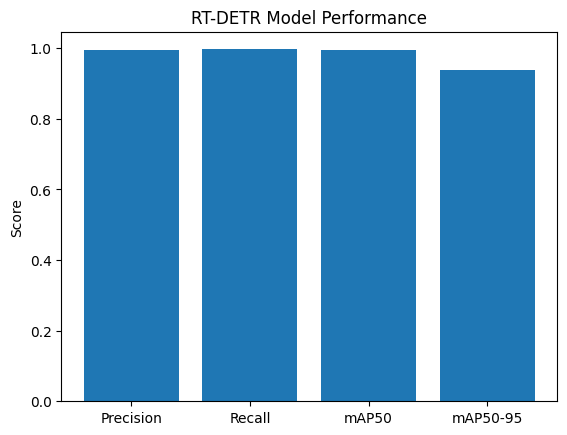

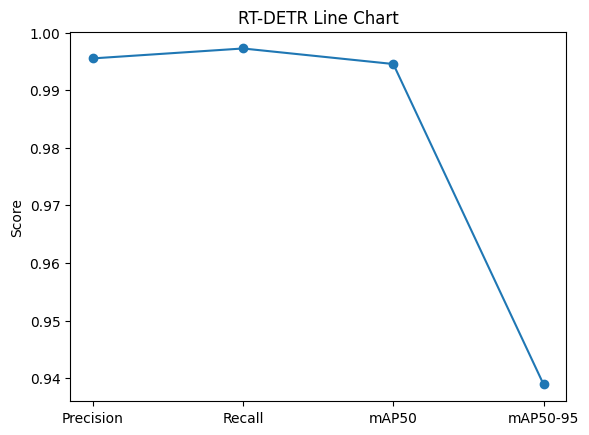

<Figure size 640x480 with 0 Axes>

In [ ]:
!pip install ultralytics

from ultralytics import RTDETR
import matplotlib.pyplot as plt
import numpy as np

model = RTDETR("/content/drive/MyDrive/pklot_models/best1.pt")

yaml_path = "/content/drive/MyDrive/pklot_yolo21/data.yaml"
results = model.val(data=yaml_path)

precision = results.box.mp
recall = results.box.mr
map50 = results.box.map50
map5095 = results.box.map

metrics_names = ["Precision", "Recall", "mAP50", "mAP50-95"]
values = [precision, recall, map50, map5095]

plt.figure()
plt.bar(metrics_names, values)
plt.ylabel("Score")
plt.title("RT-DETR Model Performance")
plt.show()

plt.figure()
plt.plot(metrics_names, values, marker='o')
plt.ylabel("Score")
plt.title("RT-DETR Line Chart")
plt.show()

plt.savefig("rtdetr_performance.png", dpi=300)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 0.4±0.1 MB/s, size: 318.4 KB)
val: Scanning /content/drive/MyDrive/pklot_yolo21/val/labels.cache... 670 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 670/670 87.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 42/42 1.2s/it 50.4s
                   all        670      63722      0.997      0.997      0.995      0.924
   

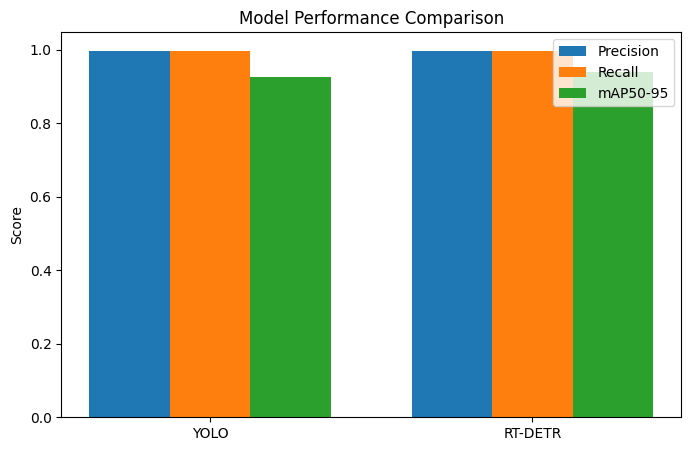

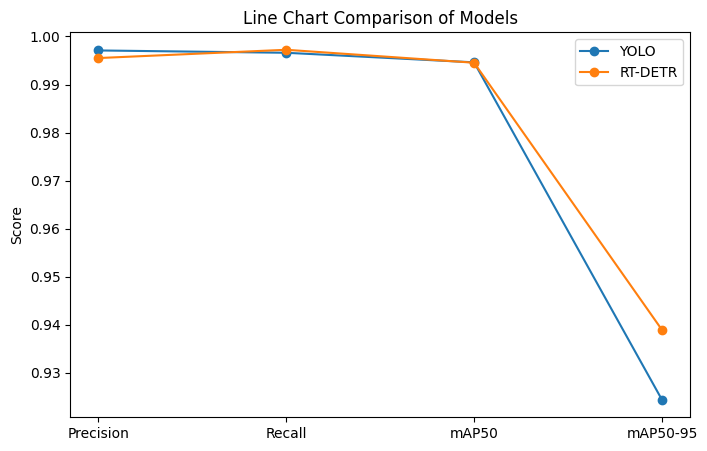

✅ All validation results copied to Google Drive!


In [ ]:
# ===============================
# 1️⃣ Install Ultralytics
# ===============================
!pip install ultralytics

from ultralytics import YOLO, RTDETR
import matplotlib.pyplot as plt
import numpy as np
import shutil
import os

# ===============================
# 2️⃣ Load Models
# ===============================
model1 = YOLO("/content/drive/MyDrive/pklot_models/best.pt")
model2 = RTDETR("/content/drive/MyDrive/pklot_models/best1.pt")

yaml_path = "/content/drive/MyDrive/pklot_yolo21/data.yaml"

# ===============================
# 3️⃣ Run Validation (creates runs/detect/val)
# ===============================
results_yolo = model1.val(data=yaml_path, save_json=True)
results_rtdetr = model2.val(data=yaml_path, save_json=True)

# ===============================
# 4️⃣ Extract Metrics
# ===============================
yolo_precision = results_yolo.box.mp
yolo_recall = results_yolo.box.mr
yolo_map50 = results_yolo.box.map50
yolo_map5095 = results_yolo.box.map

rtdetr_precision = results_rtdetr.box.mp
rtdetr_recall = results_rtdetr.box.mr
rtdetr_map50 = results_rtdetr.box.map50
rtdetr_map5095 = results_rtdetr.box.map

print("YOLO mAP50-95:", yolo_map5095)
print("RT-DETR mAP50-95:", rtdetr_map5095)

# ===============================
# 5️⃣ BAR GRAPH COMPARISON
# ===============================
models = ["YOLO", "RT-DETR"]

precision = [yolo_precision, rtdetr_precision]
recall = [yolo_recall, rtdetr_recall]
map5095 = [yolo_map5095, rtdetr_map5095]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, map5095, width, label="mAP50-95")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.savefig("bar_comparison.png", dpi=300)
plt.show()

# ===============================
# 6️⃣ LINE CHART COMPARISON
# ===============================
metrics_names = ["Precision", "Recall", "mAP50", "mAP50-95"]

yolo_values = [
    yolo_precision,
    yolo_recall,
    yolo_map50,
    yolo_map5095
]

rtdetr_values = [
    rtdetr_precision,
    rtdetr_recall,
    rtdetr_map50,
    rtdetr_map5095
]

plt.figure(figsize=(8,5))

plt.plot(metrics_names, yolo_values, marker='o', label="YOLO")
plt.plot(metrics_names, rtdetr_values, marker='o', label="RT-DETR")

plt.ylabel("Score")
plt.title("Line Chart Comparison of Models")
plt.legend()

plt.savefig("line_comparison.png", dpi=300)
plt.show()

# ===============================
# 7️⃣ Copy ALL validation PNGs to Drive
# (confusion matrix, PR curve, F1 curve, etc.)
# ===============================

source_folder = "/content/runs/detect"
destination_folder = "/content/drive/MyDrive/model_validation_results"

shutil.copytree(source_folder, destination_folder, dirs_exist_ok=True)

print("✅ All validation results copied to Google Drive!")

In [ ]:
!ls runs

detect


In [ ]:
!cp -r runs /content/drive/MyDrive/

In [ ]:
import os

SAVE_PATH = "/content/drive/MyDrive/parking_results"
os.makedirs(SAVE_PATH, exist_ok=True)

In [ ]:
import shutil

SOURCE = "/content/runs/detect"

shutil.copytree(
    SOURCE,
    SAVE_PATH + "/detect_runs",
    dirs_exist_ok=True   # allows overwrite safely
)

print("✅ All validation results copied to Drive!")

✅ All validation results copied to Drive!


In [ ]:
import xml.etree.ElementTree as ET

def parse_xml_slots(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    slots = []

    for space in root.findall("space"):
        contour = space.find("contour")
        if contour is None:
            continue

        polygon = []
        for p in contour.findall("point"):
            polygon.append((int(p.get("x")), int(p.get("y"))))

        if len(polygon) >= 3:
            xs = [p[0] for p in polygon]
            ys = [p[1] for p in polygon]

            bbox = (
                min(xs),
                min(ys),
                max(xs),
                max(ys)
            )

            slots.append(bbox)

    return slots

In [ ]:
!pip install ultralytics
from ultralytics import YOLO, RTDETR

# choose one
model1 = YOLO("/content/drive/MyDrive/pklot_models/best.pt")
model2 = RTDETR("/content/drive/MyDrive/pklot_models/best1.pt")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import cv2

def detect_parking_from_xml(image_path, xml_path):

    img = cv2.imread(image_path)
    slots = parse_xml_slots(xml_path)

    free = 0
    occupied = 0

    for (x1, y1, x2, y2) in slots:

        roi = img[y1:y2, x1:x2]

        if roi.size == 0:
            continue

        # run model on slot only
        results = model2.predict(roi, conf=0.4, verbose=False)

        boxes = results[0].boxes

        # If car detected → occupied
        if boxes is not None and len(boxes) > 0:
            color = (0,0,255)   # red
            occupied += 1
        else:
            color = (0,255,0)   # green
            free += 1

        cv2.rectangle(img,(x1,y1),(x2,y2),color,2)

    total = free + occupied

    cv2.putText(img,f"Free: {free}",(20,40),
                cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)

    cv2.putText(img,f"Occupied: {occupied}",(20,80),
                cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2)

    cv2.putText(img,f"Total: {total}",(20,120),
                cv2.FONT_HERSHEY_SIMPLEX,1,(255,255,255),2)

    return img

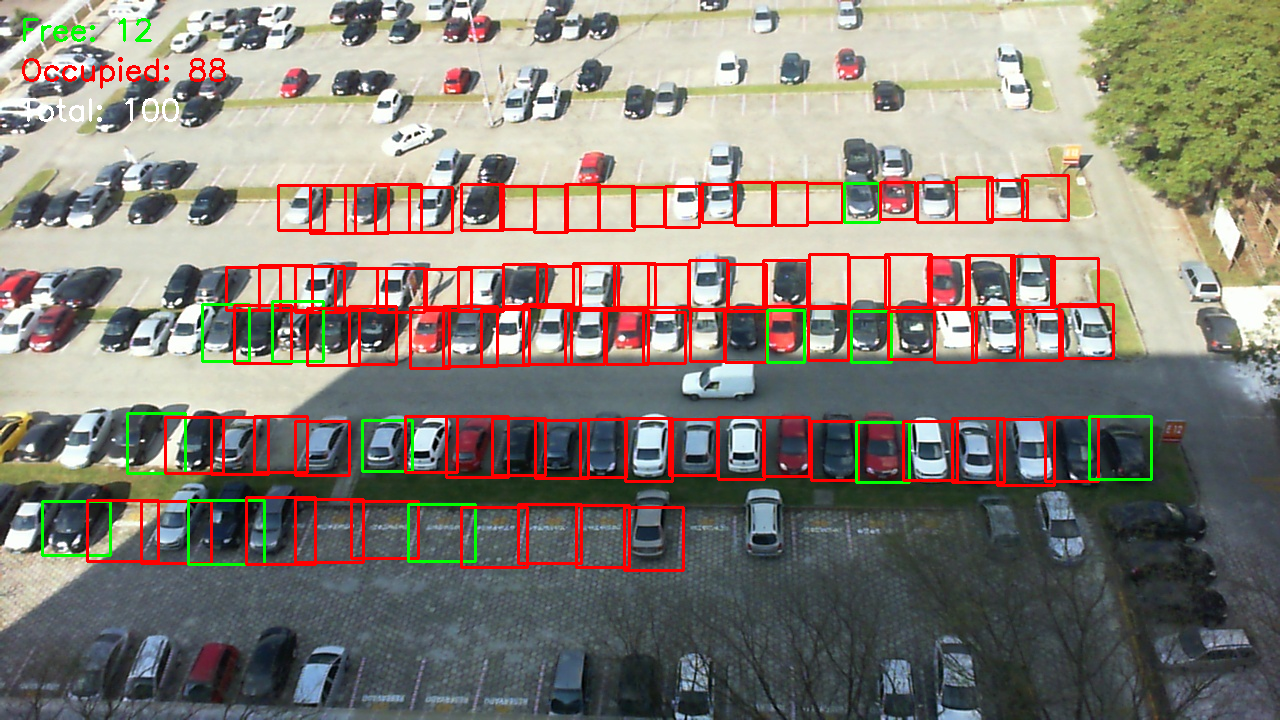

In [ ]:
result = detect_parking_from_xml(
    "/content/drive/MyDrive/PKLot_PUCPR/PUCPR/Sunny/2012-09-11/2012-09-11_15_16_58.jpg",
    "/content/drive/MyDrive/PKLot_PUCPR/PUCPR/Sunny/2012-09-11/2012-09-11_15_16_58.xml"
)

from google.colab.patches import cv2_imshow
cv2_imshow(result)

Free: 0
Occupied: 0


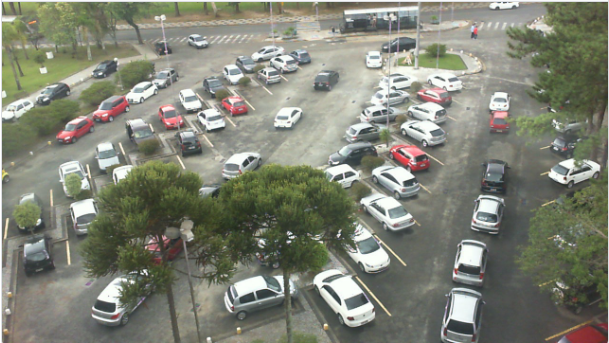

In [ ]:
from ultralytics import RTDETR
import cv2


def detect_full_image(image_path):

    results = model2.predict(image_path, conf=0.15)

    img = cv2.imread(image_path)

    free = 0
    occupied = 0

    boxes = results[0].boxes.xyxy.cpu().numpy()
    classes = results[0].boxes.cls.cpu().numpy()

    for box, cls in zip(boxes, classes):
        x1, y1, x2, y2 = map(int, box)

        if int(cls) == 0:   # empty
            color = (0,255,0)
            free += 1
        else:
            color = (0,0,255)
            occupied += 1

        cv2.rectangle(img,(x1,y1),(x2,y2),color,2)

    print("Free:", free)
    print("Occupied:", occupied)

    return img
from google.colab.patches import cv2_imshow

output = detect_full_image("/content/Screenshot 2026-02-21 104502.png")
cv2_imshow(output)